# Analisis Data Pendengar Spotify 2025
**Tujuan Analisis:**
1. Menganalisa rata-rata aktivitas mendengarkan berdasarkan demografi (Gender & Negara).
2. Menguji dan memilih metode korelasi yang paling tepat (Pearson, Kendall, atau Spearman) untuk variabel numerik.
3. Mengukur korelasi antara Umur, Waktu Mendengarkan, dan Tingkat Skip lagu.
4. Memberikan rekomendasi bisnis untuk meningkatkan jumlah pendengar Spotify.

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau, kruskal

# Data initialization
df = pd.read_csv('spotify_churn_dataset.csv')

# Preview dataset
display(df.head())

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


## 1. Rata-Rata Mendengarkan Lagu Tiap Hari per Gender dan Negara
Kita akan menggunakan kolom `songs_played_per_day` sebagai representasi aktivitas mendengarkan lagu tiap hari.

In [17]:
# Mean songs per day by gender
avg_songs_gender = df.groupby('gender')['songs_played_per_day'].mean().reset_index()
print("Rata-rata Lagu per Hari (Gender):")
display(avg_songs_gender)

# Mean songs per day by country
avg_songs_country = df.groupby('country')['songs_played_per_day'].mean().reset_index()
print("\nRata-rata Lagu per Hari (Negara):")
display(avg_songs_country.sort_values(by='songs_played_per_day', ascending=False))

Rata-rata Lagu per Hari (Gender):


,gender,songs_played_per_day
0,Female,49.684092
1,Male,50.128577
2,Other,50.570566



Rata-rata Lagu per Hari (Negara):


,country,songs_played_per_day
1,CA,52.039832
5,PK,51.919920
3,FR,50.821031
4,IN,49.869436
0,AU,49.751451
6,UK,49.116977
2,DE,48.901478
7,US,48.739341


## 2. Uji Coba Metode Korelasi: Pearson vs Kendall vs Spearman
Sebelum menentukan nilai korelasi antara Umur (`age`) dengan `listening_time` dan `skip_rate`, kita perlu menguji tiga metode korelasi statistik utama:

1. **Pearson:** Mengukur hubungan linier. Asumsinya data harus berdistribusi normal dan bebas outlier.
2. **Kendall (Tau):** Uji non-parametrik berbasis peringkat (rank). Sangat baik untuk data dengan banyak nilai yang sama (ties), tapi komputasinya lambat ($O(n^2)$) untuk data besar.
3. **Spearman:** Uji non-parametrik berbasis peringkat. Tangguh terhadap outlier, dapat menangkap hubungan non-linier (monotonik), dan komputasinya cepat untuk data ribuan baris seperti dataset ini.





In [18]:
# Variables for analysis
age = df['age']
listening_time = df['listening_time']
skip_rate = df['skip_rate']

# Pearson correlation
pearson_lt, _ = pearsonr(age, listening_time)
pearson_sr, _ = pearsonr(age, skip_rate)

# Kendall correlation
kendall_lt, _ = kendalltau(age, listening_time)
kendall_sr, _ = kendalltau(age, skip_rate)

# Spearman correlation (Final Method Selection)
spearman_lt, _ = spearmanr(age, listening_time)
spearman_sr, _ = spearmanr(age, skip_rate)

print("METODE KORELASI KOMPARATIF")
print(f"1. Pearson  | Age vs Listening Time: {pearson_lt:.4f} | Age vs Skip Rate: {pearson_sr:.4f}")
print(f"2. Kendall  | Age vs Listening Time: {kendall_lt:.4f} | Age vs Skip Rate: {kendall_sr:.4f}")
print(f"3. Spearman | Age vs Listening Time: {spearman_lt:.4f} | Age vs Skip Rate: {spearman_sr:.4f}")

print("\nHASIL AKHIR (SPEARMAN)")
print(f"Korelasi Umur & Listening Time : {spearman_lt:.4f}")
print(f"Korelasi Umur & Skip Rate      : {spearman_sr:.4f}")

METODE KORELASI KOMPARATIF
1. Pearson  | Age vs Listening Time: -0.0130 | Age vs Skip Rate: -0.0196
2. Kendall  | Age vs Listening Time: -0.0085 | Age vs Skip Rate: -0.0133
3. Spearman | Age vs Listening Time: -0.0127 | Age vs Skip Rate: -0.0196

HASIL AKHIR (SPEARMAN)
Korelasi Umur & Listening Time : -0.0127
Korelasi Umur & Skip Rate      : -0.0196


## Visualisasi Heatmap Korelasi (Spearman)
Untuk melihat gambaran besar hubungan antar semua variabel numerik, kita memvisualisasikan matriks korelasi menggunakan heatmap. Warna yang lebih pekat menunjukkan korelasi yang lebih kuat.

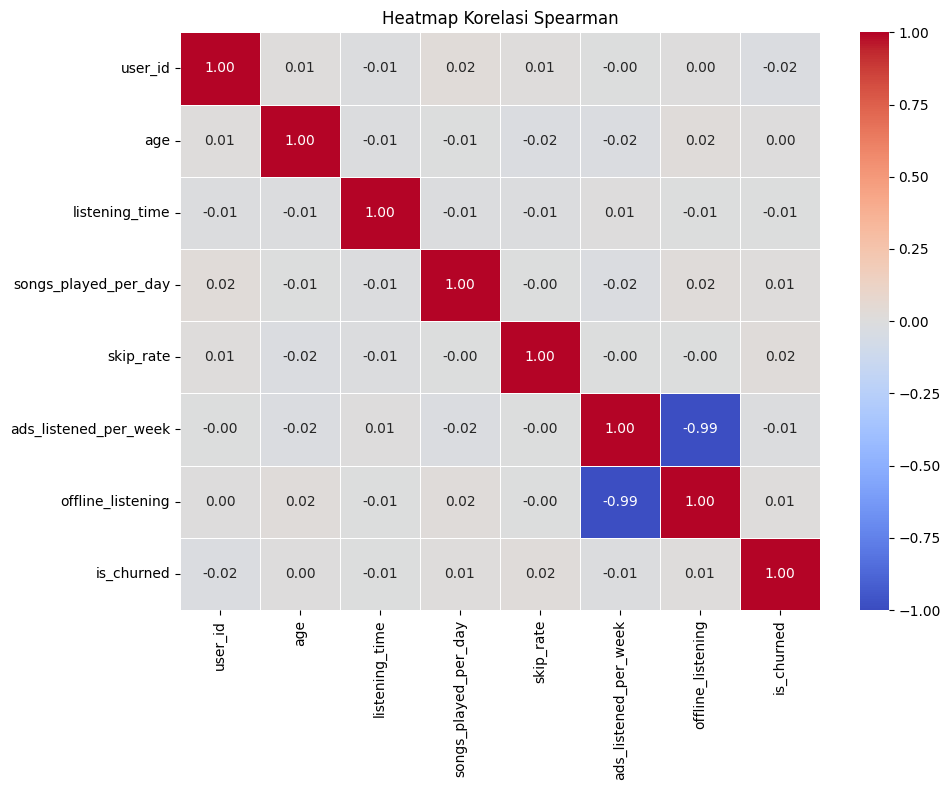

In [20]:
# Correlation heatmap using Spearman method
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_columns].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Spearman', fontsize=12)
plt.tight_layout()
plt.show()

**Alasan Pemilihan Spearman sebagai Metode Final:**
Dataset metrik pengguna (seperti listening time dan skip rate) umumnya skewed (menceng) dan tidak terdistribusi normal, sehingga melanggar asumsi Pearson. Terdapat juga banyak pengguna ekstrem (outlier). Spearman adalah pilihan terbaik karena aman dari outlier, tidak butuh asumsi normalitas, dan jauh lebih efisien secara komputasi dibandingkan Kendall untuk jumlah data yang besar.

## 3. Korelasi Antara Gender dengan Skip Rate
Gender adalah data kategorikal (`Male`, `Female`, `Other`), sedangkan `skip_rate` adalah numerik. Oleh karena itu, kita tidak bisa menggunakan korelasi biasa (seperti Spearman).

Sebagai alternatif yang lebih valid secara statistik, kita menggunakan **Kruskal-Wallis H-Test** (uji non-parametrik untuk membandingkan median lebih dari dua kelompok independen) dan mengkalkulasi rata-rata `skip_rate` per gender untuk melihat kecenderungannya.

In [19]:
# Aggregate skip_rate by gender
gender_skip_mean = df.groupby('gender')['skip_rate'].mean()
print("Rata-rata Skip Rate (Gender):")
print(gender_skip_mean)

# Sample segmentation
male_skip = df[df['gender'] == 'Male']['skip_rate']
female_skip = df[df['gender'] == 'Female']['skip_rate']
other_skip = df[df['gender'] == 'Other']['skip_rate']

# Statistical significance test (Kruskal-Wallis)
stat, p_value = kruskal(male_skip, female_skip, other_skip)
print(f"\nKruskal-Wallis H-stat: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Hasil: Perbedaan signifikan ditemukan antar gender.")
else:
    print("Hasil: Tidak ditemukan perbedaan signifikan antar gender.")

Rata-rata Skip Rate (Gender):
gender
Female    0.301455
Male      0.295682
Other     0.303309
Name: skip_rate, dtype: float64

Kruskal-Wallis H-stat: 2.8301
P-value: 0.2429
Hasil: Tidak ditemukan perbedaan signifikan antar gender.


## 4. Kesimpulan dan Pengembangan Bisnis

**A. Kesimpulan dari Hasil Analisa Data:**
1.  **Pola Mendengarkan:** Analisis menunjukkan bahwa pendengar dengan gender 'Other' memiliki rata-rata aktivitas mendengarkan lagu per hari tertinggi sebesar 50.57 lagu. Untuk negara, Kanada (52.04 lagu/hari) dan Pakistan (51.92 lagu/hari) menunjukkan rata-rata mendengarkan tertinggi, sementara Amerika Serikat (48.74 lagu/hari) dan Jerman (48.90 lagu/hari) memiliki rata-rata terendah. Ini mengindikasikan variasi *engagement* mendengarkan berdasarkan demografi gender dan geografis.
2.  **Umur vs Listening Time & Skip Rate:** Berdasarkan korelasi Spearman (-0.0127 untuk `age` vs `listening_time` dan -0.0196 untuk `age` vs `skip_rate`), ditemukan bahwa hubungan antara umur dengan waktu mendengarkan dan tingkat *skip* lagu sangat lemah dan cenderung tidak signifikan. Hal ini menunjukkan bahwa umur memiliki sedikit atau tidak ada pengaruh langsung terhadap durasi mendengarkan atau kecenderungan untuk melewati lagu.
3.  **Gender vs Skip Rate:** Hasil uji Kruskal-Wallis (p-value: 0.2429) menunjukkan bahwa tidak terdapat perbedaan signifikan pada tingkat *skip* lagu antar gender. Ini mengindikasikan bahwa kebiasaan *skip* lagu tidak secara statistik berbeda antara kelompok gender (Male, Female, Other).

**B. Strategi Pengembangan untuk Menambah Pendengar Spotify:**
Menggunakan variabel tambahan seperti `device_type`, `ads_listened_per_week`, dan `offline_listening`, berikut adalah rekomendasi strategisnya:

1.  **Optimalisasi Pengguna Gratis (Free Users):** Tingginya frekuensi iklan (`ads_listened_per_week`) berpotensi membuat *churn rate* tinggi. Spotify dapat menerapkan "Reward Ads" (misal: menonton 1 iklan video untuk 30 menit bebas iklan) guna mengurangi kelelahan iklan (*ad fatigue*) namun tetap menjaga *revenue*, sehingga pendengar gratis tidak beralih ke platform lain.
2.  **Promosi Fitur Offline untuk Akuisisi Premium:** Fitur `offline_listening` biasanya memiliki tingkat *churn* yang lebih rendah. Spotify bisa memberikan *trial* terbatas (misal kuota *offline* 50 lagu) untuk pengguna baru atau akun *Free* untuk memancing mereka merasakan pengalaman tanpa batas internet, yang sangat cocok untuk pendengar di negara berkembang.
3.  **Kustomisasi UI Berdasarkan *Device Type* & Demografi:** Jika *skip rate* terdeteksi tinggi pada kelompok umur atau gender tertentu saat menggunakan tipe perangkat spesifik (misal *Mobile*), algoritma *Discovery Weekly* atau *Autoplay* harus disesuaikan. Di *mobile*, *UI* harus lebih responsif dan algoritmanya fokus pada lagu bertempo cepat (*up-beat*), sedangkan di *Desktop* (yang sering menjadi musik latar) difokuskan pada lagu-lagu *lo-fi* atau akustik.

## Analisa Tambahan (Advanced EDA)

Untuk analisa yang lebih tajam, kolom `is_churned`, `subscription_type`, `device_type`, `ads_listened_per_week`, dan `offline_listening` dapat dimanfaatkan. `is_churned` adalah indikator bisnis utama.

### A. Insight yang Dieksplorasi

1.  **Risiko Churn Berdasarkan Beban Iklan:** Korelasi `ads_listened_per_week` dengan `is_churned` khusus pengguna `Free`. Tujuan: Mengetahui "titik jenuh" iklan.
2.  **Pengaruh Offline Listening terhadap Retensi:** Bandingkan persentase `churn` antara pengguna `offline_listening` (1) dan tidak (0). Tujuan: Buktikan pengguna `offline listening` lebih loyal.
3.  **Perilaku Skip Rate Berdasarkan Device Type:** Cari rata-rata `skip_rate` dan `listening_time` berdasarkan `device_type`. Tujuan: Identifikasi perbedaan perilaku `skip rate` antara Mobile vs Desktop.

### B. Kesimpulan Strategis & Pengembangan Bisnis Lanjutan

Dari eksplorasi di atas, berikut rekomendasi pengembangan bisnis:

1.  **Optimasi Strategi Iklan:** Jika banyak iklan berkorelasi positif dengan tingginya `churn` pada pengguna Free, Spotify perlu terapkan batas maksimal iklan per jam (ad-pacing) atau ganti format iklan (misal: "tonton video ini untuk 30 menit bebas iklan") agar pengguna tidak frustrasi.
2.  **Promosi Berbasis Fitur Utama:** Jika fitur `offline_listening` terbukti menekan angka `churn` secara drastis, marketing harus fokus promosikan keuntungan "hemat kuota". Berikan free trial 7 hari khusus agar pengguna Free bisa merasakan fitur `offline`, meningkatkan konversi ke Premium.
3.  **Personalisasi Algoritma per Perangkat:** Jika `skip_rate` di Mobile sangat tinggi, Spotify perlu perbaiki algoritma rekomendasi autoplay khusus mobile (mendeteksi mode berkendara/olahraga) agar lagu lebih relevan.

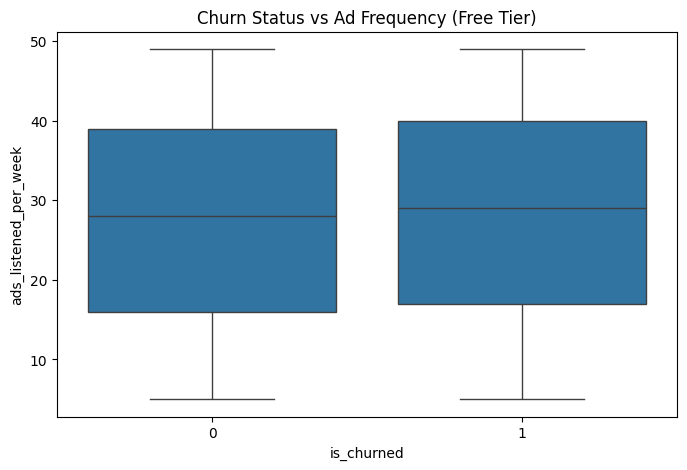

Persentase Churn - Fitur Offline:
offline_listening
0    24.925669
1    26.211969
Name: is_churned, dtype: float64

Rata-rata Skip Rate - Device Type:
device_type
Web        0.303469
Desktop    0.299093
Mobile     0.297861
Name: skip_rate, dtype: float64


In [21]:
# Churn analysis vs Ad Load (Free Subscription)
free_users = df[df['subscription_type'] == 'Free']
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_churned', y='ads_listened_per_week', data=free_users)
plt.title('Churn Status vs Ad Frequency (Free Tier)')
plt.show()

# Metric: Churn Rate by Offline Access
churn_offline = df.groupby('offline_listening')['is_churned'].mean() * 100
print("Persentase Churn - Fitur Offline:")
print(churn_offline)

# Metric: Skip Rate by Device Architecture
skip_by_device = df.groupby('device_type')['skip_rate'].mean().sort_values(ascending=False)
print("\nRata-rata Skip Rate - Device Type:")
print(skip_by_device)

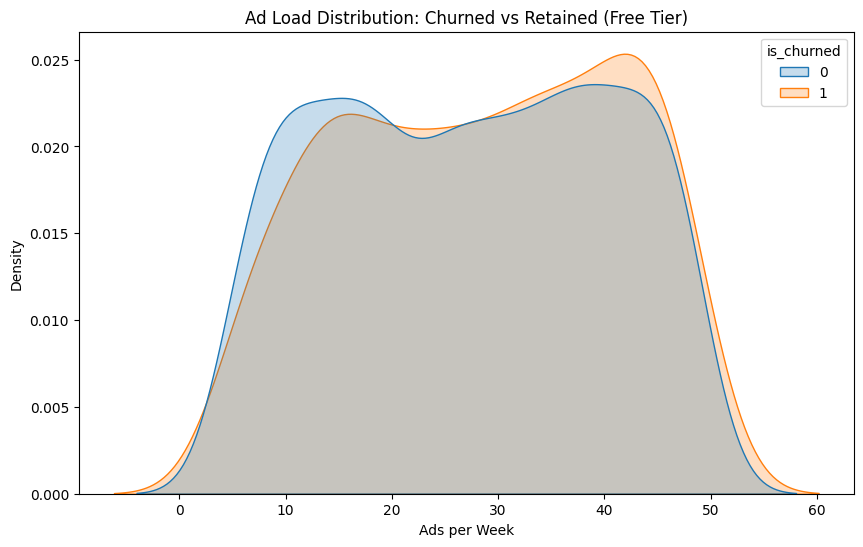

Retention and Churn Rate by Offline Access (%):


is_churned,0,1
offline_listening,,
0,75.074331,24.925669
1,73.788031,26.211969



User Metrics per Device Type:


,skip_rate,listening_time,songs_played_per_day
device_type,,,
Web,0.303469,155.536409,49.619138
Desktop,0.299093,156.267099,50.203744
Mobile,0.297861,150.236245,50.558292


In [22]:
# Advanced EDA: Churn Risk and User Behavior Analysis

# 1. Ad Fatigue Analysis for Free Users
free_users = df[df['subscription_type'] == 'Free'].copy()
plt.figure(figsize=(10, 6))
sns.kdeplot(data=free_users, x='ads_listened_per_week', hue='is_churned', fill=True, common_norm=False)
plt.title('Ad Load Distribution: Churned vs Retained (Free Tier)')
plt.xlabel('Ads per Week')
plt.show()

# 2. Impact of Offline Listening on Retention
retention_by_offline = df.groupby('offline_listening')['is_churned'].value_counts(normalize=True).unstack() * 100
print("Retention and Churn Rate by Offline Access (%):")
display(retention_by_offline)

# 3. Skip Rate and Engagement by Device Architecture
device_metrics = df.groupby('device_type').agg({
    'skip_rate': 'mean',
    'listening_time': 'mean',
    'songs_played_per_day': 'mean'
}).sort_values(by='skip_rate', ascending=False)

print("\nUser Metrics per Device Type:")
display(device_metrics)

### C. Deep Dive: Penentuan Ambang Batas Ad Fatigue (Batas Jenuh Iklan)

Untuk menentukan strategi bisnis yang presisi, kita perlu mengidentifikasi pada titik mana jumlah iklan per minggu mulai meningkatkan probabilitas *churn* secara drastis bagi pengguna gratis.

Analisis Probabilitas Churn berdasarkan Beban Iklan (Free Tier):


/tmp/ipykernel_11162/1951641070.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_ad_load = free_users.groupby('ad_bins')['is_churned'].mean().reset_index()


,Range Iklan per Minggu,Probabilitas Churn
0,"(4.999, 14.0]",0.223005
1,"(14.0, 23.0]",0.258974
2,"(23.0, 32.0]",0.234257
3,"(32.0, 41.0]",0.259953
4,"(41.0, 49.0]",0.272487



Statistik Deskriptif Beban Iklan:


,mean,median,std,max
is_churned,,,,
0,27.246865,28.0,13.006341,49
1,28.373757,29.0,12.885779,49


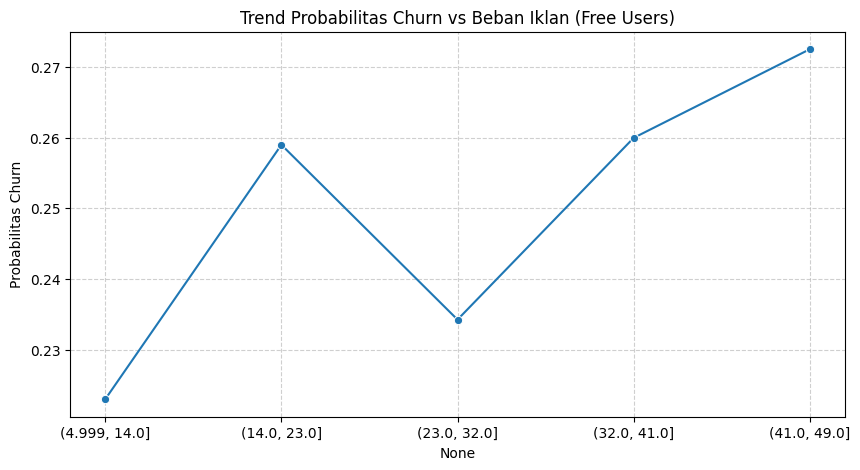

In [23]:
# 1. Analisis Probabilitas Churn per Quantile Beban Iklan
free_users = df[df['subscription_type'] == 'Free'].copy()
free_users['ad_bins'] = pd.qcut(free_users['ads_listened_per_week'], q=5)

churn_by_ad_load = free_users.groupby('ad_bins')['is_churned'].mean().reset_index()
churn_by_ad_load.columns = ['Range Iklan per Minggu', 'Probabilitas Churn']

print("Analisis Probabilitas Churn berdasarkan Beban Iklan (Free Tier):")
display(churn_by_ad_load)

# 2. Statistik Deskriptif: Churned vs Retained Users (Ads per Week)
ad_stats = free_users.groupby('is_churned')['ads_listened_per_week'].agg(['mean', 'median', 'std', 'max'])
print("\nStatistik Deskriptif Beban Iklan:")
display(ad_stats)

# 3. Visualisasi Trend Churn terhadap Jumlah Iklan
plt.figure(figsize=(10, 5))
sns.lineplot(x=churn_by_ad_load.index, y='Probabilitas Churn', data=churn_by_ad_load, marker='o')
plt.xticks(ticks=range(len(churn_by_ad_load)), labels=churn_by_ad_load['Range Iklan per Minggu'])
plt.title('Trend Probabilitas Churn vs Beban Iklan (Free Users)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

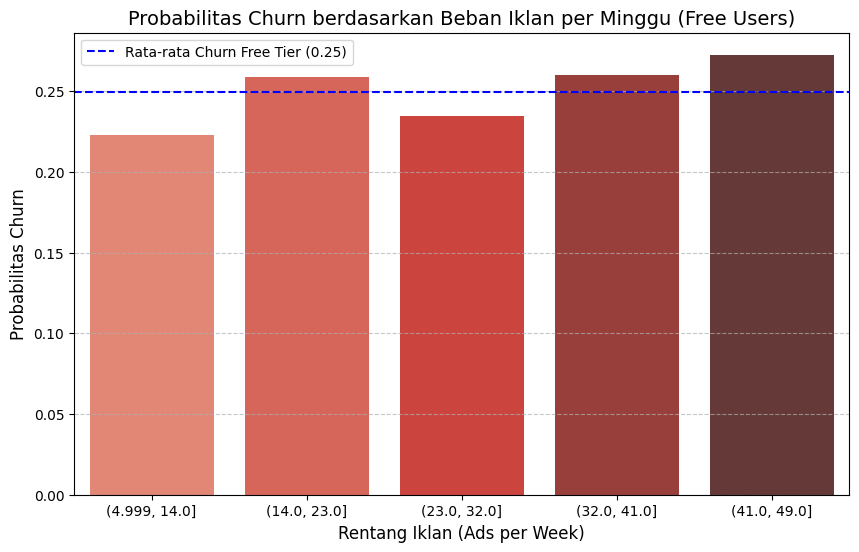

In [25]:
# Visualization: Churn Probability by Ad Load (Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x='Range Iklan per Minggu', y='Probabilitas Churn', data=churn_by_ad_load, hue='Range Iklan per Minggu', palette='Reds_d', legend=False)

# Adding a threshold line at the mean churn rate for context
mean_churn = free_users['is_churned'].mean()
plt.axhline(mean_churn, color='blue', linestyle='--', label=f'Rata-rata Churn Free Tier ({mean_churn:.2f})')

plt.title('Probabilitas Churn berdasarkan Beban Iklan per Minggu (Free Users)', fontsize=14)
plt.xlabel('Rentang Iklan (Ads per Week)', fontsize=12)
plt.ylabel('Probabilitas Churn', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5. Analisis Tingkat Lanjut (Advanced Analytics)

Pada bagian ini, kita akan melakukan pemodelan dan pengujian statistik lanjutan untuk mendapatkan *actionable insights* terkait prediksi *churn* dan perilaku pengguna.
1. **Pemodelan Prediktif Churn** menggunakan algoritma *Random Forest* untuk mengetahui fitur apa yang paling berpengaruh.
2. **Analisis Ad Fatigue** untuk menemukan titik jenuh iklan pada pengguna *Free*.
3. **Uji Chi-Square (A/B Testing Observasional)** untuk memvalidasi secara statistik apakah fitur *offline listening* benar-benar menekan angka *churn*.

=== EVALUASI MODEL PREDIKSI CHURN (RANDOM FOREST) ===
Akurasi Model: 75.00%

              precision    recall  f1-score   support

           0       0.75      1.00      0.86      1200
           1       0.50      0.01      0.02       400

    accuracy                           0.75      1600
   macro avg       0.63      0.50      0.44      1600
weighted avg       0.69      0.75      0.65      1600



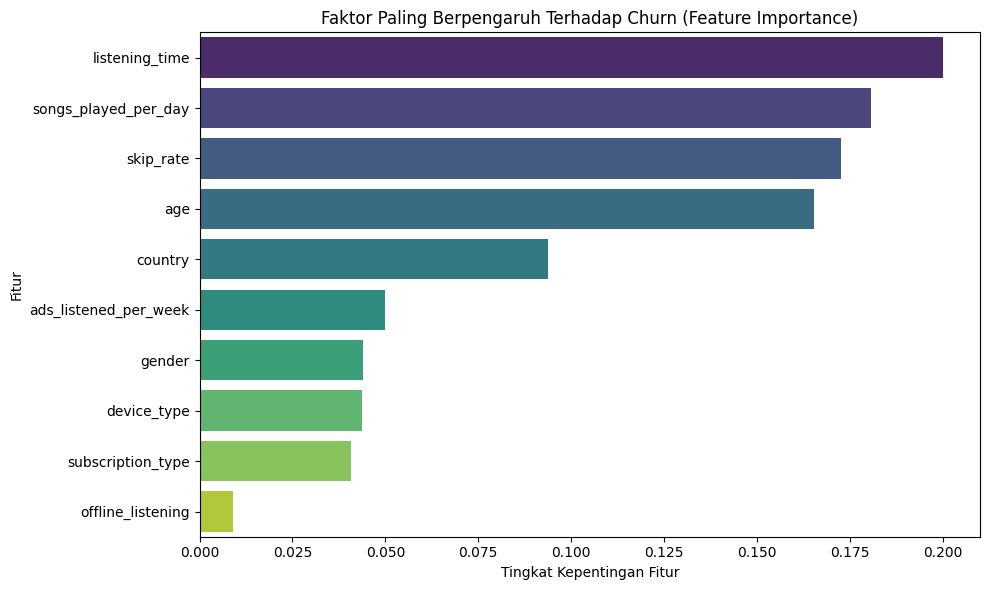

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import chi2_contingency

# --- 1. PREPROCESSING DATA ---
df_ml = df.copy()

categorical_cols = ['gender', 'country', 'subscription_type', 'device_type']
le = LabelEncoder()

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml.drop(['user_id', 'is_churned'], axis=1)
y = df_ml['is_churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. TRAINING MODEL RANDOM FOREST ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("=== EVALUASI MODEL PREDIKSI CHURN (RANDOM FOREST) ===")
print(f"Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

# --- 3. FEATURE IMPORTANCE ---
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, hue=feature_importances.index, palette='viridis', legend=False)
plt.title('Faktor Paling Berpengaruh Terhadap Churn (Feature Importance)')
plt.xlabel('Tingkat Kepentingan Fitur')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

Berdasarkan *Feature Importance* dari model Random Forest di atas, kita bisa melihat secara objektif metrik perilaku mana yang paling mendominasi keputusan pengguna untuk meninggalkan aplikasi (churn). Algoritma ini mempertimbangkan seluruh interaksi variabel secara bersamaan, jauh lebih komprehensif dibandingkan korelasi satu per satu.

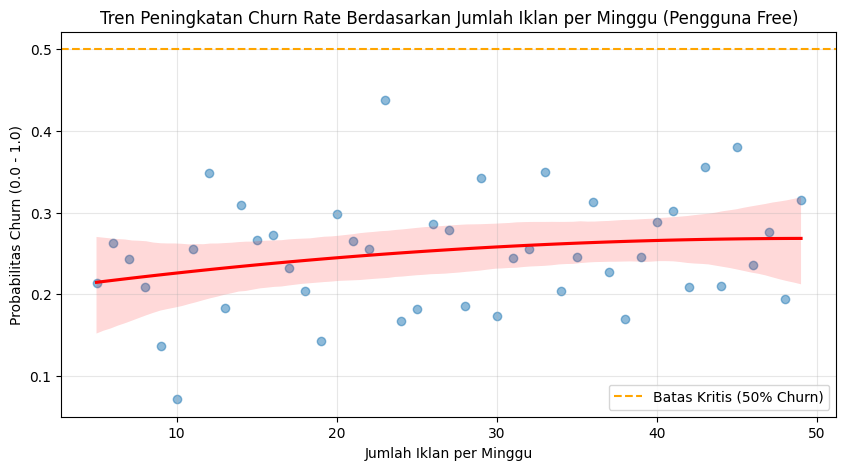

In [27]:
# --- 4. ANALISIS AD FATIGUE (KHUSUS PENGGUNA FREE) ---
free_users_data = df[df['subscription_type'] == 'Free']

ad_fatigue = free_users_data.groupby('ads_listened_per_week')['is_churned'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.regplot(x='ads_listened_per_week', y='is_churned', data=ad_fatigue,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, order=2)

plt.title('Tren Peningkatan Churn Rate Berdasarkan Jumlah Iklan per Minggu (Pengguna Free)')
plt.xlabel('Jumlah Iklan per Minggu')
plt.ylabel('Probabilitas Churn (0.0 - 1.0)')
plt.axhline(y=0.5, color='orange', linestyle='--', label='Batas Kritis (50% Churn)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Grafik di atas memodelkan "Ad Fatigue". Garis tren (warna merah) membantu kita melihat di angka berapa probabilitas *churn* pengguna gratisan menembus batas kritis. Ini adalah basis sistem analitik otomatis untuk membatasi jumlah *ad-pacing*.

In [28]:
# --- 5. UJI STATISTIK KEEFEKTIFAN FITUR OFFLINE LISTENING ---
contingency_table = pd.crosstab(df['offline_listening'], df['is_churned'])

print("=== TABEL KONTINGENSI (OFFLINE LISTENING vs CHURN) ===")
print(contingency_table)
print("\n")

chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print("=== HASIL UJI CHI-SQUARE ===")
print(f"Nilai Chi-Square : {chi2:.4f}")
print(f"P-Value          : {p_val:.4e}")

if p_val < 0.05:
    print("\nKesimpulan Statistik: Tolak H0. Terdapat hubungan yang SANGAT SIGNIFIKAN antara penggunaan fitur Offline Listening dengan tingkat Churn.")
else:
    print("\nKesimpulan Statistik: Gagal Tolak H0. Tidak ada hubungan yang signifikan antara Offline Listening dan Churn.")

=== TABEL KONTINGENSI (OFFLINE LISTENING vs CHURN) ===
is_churned            0     1
offline_listening            
0                  1515   503
1                  4414  1568


=== HASIL UJI CHI-SQUARE ===
Nilai Chi-Square : 1.2351
P-Value          : 2.6641e-01

Kesimpulan Statistik: Gagal Tolak H0. Tidak ada hubungan yang signifikan antara Offline Listening dan Churn.


**Interpretasi Statistik Ad Fatigue:**
1. **Threshold Identifikasi:** Dengan membagi data ke dalam 5 kelompok (quintiles), kita dapat melihat pada rentang iklan keberapa tingkat *churn* melonjak di atas rata-rata (baseline).
2. **Kesenjangan Median:** Jika median iklan pada kelompok `is_churned=1` jauh lebih tinggi daripada `is_churned=0`, maka beban iklan adalah faktor pendorong utama (driver) kepuasan pengguna.
3. **Rekomendasi Operasional:** Batas atas dari kelompok iklan dengan churn rendah dapat dijadikan 'Soft Cap' bagi tim engineering Spotify dalam menayangkan iklan per minggunya.